<a href="https://colab.research.google.com/github/yasuhisasugiura-crypto/PARC2026_pre/blob/main/parc_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# データ可視化用ライブラリのインストール
!pip install lerobot[dataset] --quiet
!pip install matplotlib pandas numpy --quiet
!pip install opencv-python --quiet

# 環境変数（学習用と同じ設定）
import os
os.environ["HF_HOME"] = "/content/hf_cache"
os.environ["HF_LEROBOT_HOME"] = "/content/lerobot_cache"
print("✅ セットアップ完了")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 68.1 MB/s eta 0:00:00
✅ セットアップ完了


In [ ]:
from lerobot.datasets.dataset_metadata import LeRobotDatasetMetadata
from lerobot.datasets.lerobot_dataset import LeRobotDataset

DATASET_REPO = "lerobot/libero_plus"
DATASET_REVISION = "f3f49f426d75030177b18778374005bc12ccd588"

# メタデータをダウンロード
metadata = LeRobotDatasetMetadata(DATASET_REPO, revision=DATASET_REVISION)
print(f"総エピソード数: {metadata.total_episodes}")
print(f"総ステップ数: {metadata.total_frames}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

総エピソード数: 14347
総ステップ数: 2238036


In [ ]:
import re
from collections import defaultdict

SPATIAL_TASK_NAMES = [
    "pick up the black bowl from table center and place it on the plate",
    "pick up the black bowl next to the cookie box and place it on the plate",
    "pick up the black bowl next to the plate and place it on the plate",
    "pick up the black bowl next to the ramekin and place it on the plate",
    "pick up the black bowl on the cookie box and place it on the plate",
    "pick up the black bowl on the ramekin and place it on the plate",
    "pick up the black bowl on the stove and place it on the plate",
    "pick up the black bowl on the wooden cabinet and place it on the plate",
    "pick up the black bowl in the top drawer of the wooden cabinet and place it on the plate",
    "pick up the black bowl between the plate and the ramekin and place it on the plate",
]

def normalize(s):
    s = s.lower().replace("_", " ")
    s = re.sub(r"[^a-z0-9 ]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

# タスクごとのエピソードindexを取得
task_to_episodes = defaultdict(list)
for ep_idx, task_cell in enumerate(metadata.episodes["tasks"]):
    task_name = task_cell if isinstance(task_cell, str) else str(task_cell[0])
    task_to_episodes[task_name].append(ep_idx)

# Spatialタスク10種のindexを整理
spatial_task_indices = {}
for target_name in SPATIAL_TASK_NAMES:
    normalized_target = normalize(target_name)
    for actual_name, indices in task_to_episodes.items():
        if normalize(actual_name) == normalized_target:
            spatial_task_indices[target_name] = indices
            break

# 各タスクのエピソード数を表示
for name, indices in spatial_task_indices.items():
    print(f"[{len(indices)}個] {name[:60]}...")

[385個] pick up the black bowl from table center and place it on the...
[445個] pick up the black bowl next to the cookie box and place it o...
[445個] pick up the black bowl next to the plate and place it on the...
[380個] pick up the black bowl next to the ramekin and place it on t...
[385個] pick up the black bowl on the cookie box and place it on the...
[295個] pick up the black bowl on the ramekin and place it on the pl...
[255個] pick up the black bowl on the stove and place it on the plat...
[395個] pick up the black bowl on the wooden cabinet and place it on...
[390個] pick up the black bowl in the top drawer of the wooden cabin...
[375個] pick up the black bowl between the plate and the ramekin and...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 101.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


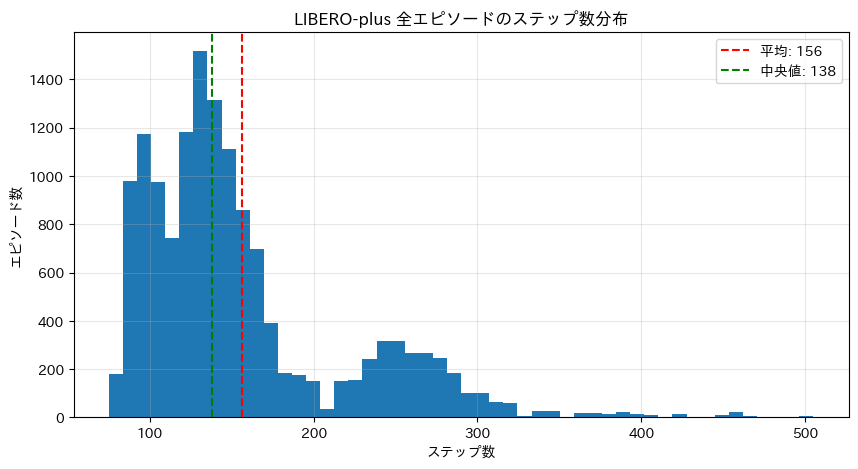

最小: 75, 最大: 505
平均: 156, 中央値: 138


In [ ]:
!pip install japanize-matplotlib --quiet
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# metadata.episodes から各エピソードのステップ数を直接取得します
episode_lengths = np.array(metadata.episodes["length"])

# ヒストグラム表示
plt.figure(figsize=(10, 5))
plt.hist(episode_lengths, bins=50)
plt.xlabel("ステップ数")
plt.ylabel("エピソード数")
plt.title("LIBERO-plus 全エピソードのステップ数分布")
plt.axvline(episode_lengths.mean(), color='red', linestyle='--', label=f'平均: {episode_lengths.mean():.0f}')
plt.axvline(np.median(episode_lengths), color='green', linestyle='--', label=f'中央値: {np.median(episode_lengths):.0f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"最小: {episode_lengths.min()}, 最大: {episode_lengths.max()}")
print(f"平均: {episode_lengths.mean():.0f}, 中央値: {np.median(episode_lengths):.0f}")

In [ ]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset

# データセットをロード（時間がかかる、初回のみ）
dataset = LeRobotDataset(DATASET_REPO, revision=DATASET_REVISION)

# 最初のSpatialタスクの最初のエピソードを見る
first_task = list(spatial_task_indices.keys())[0]
first_ep_idx = spatial_task_indices[first_task][0]
print(f"タスク: {first_task[:50]}...")
print(f"エピソード番号: {first_ep_idx}")

# エピソードの範囲を計算（episode_data_index の代わりに length から算出）
lengths = metadata.episodes["length"]
ep_from = sum(lengths[:first_ep_idx])
ep_to = ep_from + lengths[first_ep_idx]
print(f"ステップ数: {ep_to - ep_from}")

# 4つのタイミングで画像を表示（開始・1/3・2/3・終了）
timings = [ep_from, ep_from + (ep_to-ep_from)//3, ep_from + 2*(ep_to-ep_from)//3, ep_to-1]
timing_labels = ["開始", "1/3経過", "2/3経過", "終了"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, (t, label) in enumerate(zip(timings, timing_labels)):
    sample = dataset[t]
    # 正面カメラ
    front_img = sample.get("observation.images.image", None)
    if front_img is not None:
        axes[0, i].imshow(front_img.permute(1, 2, 0).numpy())
        axes[0, i].set_title(f"正面 - {label}")
        axes[0, i].axis("off")
    # 手先カメラ
    wrist_img = sample.get("observation.images.wrist_image", None)
    if wrist_img is not None:
        axes[1, i].imshow(wrist_img.permute(1, 2, 0).numpy())
        axes[1, i].set_title(f"手先 - {label}")
        axes[1, i].axis("off")
plt.tight_layout()
plt.show()

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 83 files:   0%|          | 0/83 [00:00<?, ?it/s]

In [ ]:
# 各エピソードの「悪さスコア」を計算
scores = []

lengths = metadata.episodes["length"]
ep_froms = np.concatenate([[0], np.cumsum(lengths)[:-1]])
ep_tos = np.cumsum(lengths)

for ep_idx in range(metadata.total_episodes):
    ep_from = int(ep_froms[ep_idx])
    ep_to = int(ep_tos[ep_idx])
    ep_length = ep_to - ep_from
    # このエピソード全体のactionを集める
    actions = []
    for t in range(ep_from, ep_to):
        sample = dataset[t]
        if "action" in sample:
            actions.append(sample["action"].numpy())
    actions = np.array(actions)
    # 各種指標を計算
    score = {
        "episode_idx": ep_idx,
        "length": ep_length,
        "action_std": actions.std() if len(actions) > 0 else 0,          # 動きのばらつき
        "action_max_diff": np.abs(np.diff(actions, axis=0)).max() if len(actions) > 1 else 0,  # 最大変化
        "gripper_changes": 0,                                            # gripper変化回数
    }
    if len(actions) > 0:
        # gripperは通常最後の次元
        gripper = actions[:, -1]
        score["gripper_changes"] = int(np.sum(np.diff(np.sign(gripper)) != 0))
    scores.append(score)

# DataFrameに変換
import pandas as pd
df = pd.DataFrame(scores)

# 各指標の統計
print("【エピソードの統計】")
print(df.describe())

# 異常値を検出（平均から2σ外れているもの）
mean_length = df["length"].mean()
std_length = df["length"].std()

df["is_too_long"] = df["length"] > mean_length + 2 * std_length
df["is_too_short"] = df["length"] < mean_length - 2 * std_length
df["is_too_bumpy"] = df["action_max_diff"] > df["action_max_diff"].quantile(0.95)
df["is_gripper_wobble"] = df["gripper_changes"] > 3

# 疑わしいエピソードを表示
suspicious = df[df["is_too_long"] | df["is_too_short"] | df["is_too_bumpy"] | df["is_gripper_wobble"]]
print(f"\n【疑わしいエピソード】{len(suspicious)}個")
print(suspicious.head(20))

In [ ]:
# 疑わしいエピソードから1つ選んで連続フレームを表示
def show_episode(ep_idx, n_frames=8):
    lengths = metadata.episodes["length"]
    ep_from = sum(lengths[:ep_idx])
    ep_to = ep_from + lengths[ep_idx]

    # n_frames枚を等間隔で選ぶ
    indices = np.linspace(ep_from, ep_to-1, n_frames).astype(int)
    fig, axes = plt.subplots(2, n_frames, figsize=(24, 6))
    for i, t in enumerate(indices):
        sample = dataset[t]
        front = sample.get("observation.images.image", None)
        wrist = sample.get("observation.images.wrist_image", None)
        if front is not None:
            axes[0, i].imshow(front.permute(1, 2, 0).numpy())
            axes[0, i].set_title(f"t={t-ep_from}")
            axes[0, i].axis("off")
        if wrist is not None:
            axes[1, i].imshow(wrist.permute(1, 2, 0).numpy())
            axes[1, i].axis("off")
    fig.suptitle(f"エピソード {ep_idx} (長さ={ep_to-ep_from})")
    plt.tight_layout()
    plt.show()

# 最も長いエピソードを見る
longest_ep = suspicious.sort_values("length", ascending=False).iloc[0]
print(f"最長エピソード: {longest_ep['episode_idx']}, 長さ={longest_ep['length']}")
show_episode(int(longest_ep["episode_idx"]))

In [ ]:
# 各タスクから「良質な」エピソードを選ぶ
def select_high_quality_episodes(task_indices, df, n_per_task=5):
    """各タスクから、品質スコアの高いエピソードをn個選ぶ"""
    # 各エピソードに"品質スコア"を計算
    task_df = df[df["episode_idx"].isin(task_indices)].copy()
    # 品質スコア = 悪い指標がないほど高い
    task_df["quality_score"] = 100.0
    task_df.loc[task_df["is_too_long"], "quality_score"] -= 30
    task_df.loc[task_df["is_too_short"], "quality_score"] -= 30
    task_df.loc[task_df["is_too_bumpy"], "quality_score"] -= 20
    task_df.loc[task_df["is_gripper_wobble"], "quality_score"] -= 20
    # スコア順にソートして上位n個を選ぶ
    top = task_df.sort_values("quality_score", ascending=False).head(n_per_task)
    return top["episode_idx"].tolist()

# 品質重視で50個選ぶ
quality_episodes = []
for task_name, indices in spatial_task_indices.items():
    selected = select_high_quality_episodes(indices, df, n_per_task=5)
    quality_episodes.extend(selected)
    print(f"タスク {task_name[:40]}...: 選ばれた= {selected}")

print(f"\n合計 {len(quality_episodes)}エピソード")
print(f"選ばれたエピソード: {sorted(quality_episodes)}")

# 選ばれたエピソードのindexをファイルに保存（学習Notebookで使う）
import json
with open("/content/quality_episodes.json", "w") as f:
    json.dump(sorted(quality_episodes), f)
print("✅ /content/quality_episodes.json に保存")